In [1]:
import pandas as pd

small_file = r"D:\CSE-CICIDS2018\Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv"
df_check = pd.read_csv(small_file, nrows=5)
df_check.columns = df_check.columns.str.strip()
print(f"Total columns: {len(df_check.columns)}")
print(df_check.columns.tolist())

# Check label column
print(f"\nLabel sample:")
df_label = pd.read_csv(small_file, nrows=200)
df_label.columns = df_label.columns.str.strip()
label_col = [c for c in df_label.columns if 'label' in c.lower()]
print(f"Label column name: {label_col}")
if label_col:
    print(df_label[label_col[0]].value_counts())

Total columns: 80
['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk 

In [2]:
import pandas as pd

attack_file = r"D:\CSE-CICIDS2018\Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv"
df_labels = pd.read_csv(attack_file, usecols=lambda c: c.strip() == 'Label', low_memory=False)
df_labels.columns = df_labels.columns.str.strip()
print(df_labels['Label'].value_counts())

Label
Benign            667626
FTP-BruteForce    193360
SSH-Bruteforce    187589
Name: count, dtype: int64


In [3]:
import pandas as pd
import os

path = r"D:\CSE-CICIDS2018"

for f in sorted(os.listdir(path)):
    fpath = os.path.join(path, f)
    df = pd.read_csv(fpath, usecols=lambda c: c.strip() == 'Label', low_memory=False)
    df.columns = df.columns.str.strip()
    print(f"\n{f}")
    print(df['Label'].value_counts())


Friday-02-03-2018_TrafficForML_CICFlowMeter.csv
Label
Benign    762384
Bot       286191
Name: count, dtype: int64

Friday-16-02-2018_TrafficForML_CICFlowMeter.csv
Label
DoS attacks-Hulk            461912
Benign                      446772
DoS attacks-SlowHTTPTest    139890
Label                            1
Name: count, dtype: int64

Friday-23-02-2018_TrafficForML_CICFlowMeter.csv
Label
Benign              1048009
Brute Force -Web        362
Brute Force -XSS        151
SQL Injection            53
Name: count, dtype: int64

Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv
Label
Benign                    7372557
DDoS attacks-LOIC-HTTP     576191
Name: count, dtype: int64

Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv
Label
Benign           238037
Infilteration     93063
Label                25
Name: count, dtype: int64

Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv
Label
Benign                   996077
DoS attacks-GoldenEye     41508
DoS attacks-Slowloris     10990
Name: count,

Cell 1 — Imports and Paths

In [26]:
import os, pickle, gc, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import shap
import matplotlib.pyplot as plt

DATA_PATH   = r"D:\CSE-CICIDS2018"
ARTIFACT_PATH   = r"..\artifacts"
CHECKPOINT_PATH = r"..\checkpoints"

os.makedirs(ARTIFACT_PATH, exist_ok=True)
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

FILES = [
    "Friday-02-03-2018_TrafficForML_CICFlowMeter.csv",
    "Friday-16-02-2018_TrafficForML_CICFlowMeter.csv",
    "Friday-23-02-2018_TrafficForML_CICFlowMeter.csv",
    "Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv",
    "Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv",
    "Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv",
    "Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv",
    "Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv",
    "Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv",
    "Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv",
]

print(f"Files: {len(FILES)}")
print("Imports OK")

Files: 10
Imports OK


Cell 2 — Feature List (CIC-IDS2018 column names)

In [27]:
FEATURES = [
    'Flow Duration',
    'Tot Fwd Pkts',
    'Tot Bwd Pkts',
    'TotLen Fwd Pkts',
    'TotLen Bwd Pkts',
    'Fwd Pkt Len Max',
    'Fwd Pkt Len Min',
    'Fwd Pkt Len Mean',
    'Bwd Pkt Len Max',
    'Bwd Pkt Len Min',
    'Bwd Pkt Len Mean',
    'Flow Byts/s',
    'Flow Pkts/s',
    'Flow IAT Mean',
    'Fwd IAT Mean',
    'Bwd IAT Mean',
    'Fwd PSH Flags',
    'FIN Flag Cnt',
    'SYN Flag Cnt',
    'RST Flag Cnt',
    'PSH Flag Cnt',
    'ACK Flag Cnt',
    'Down/Up Ratio',
    'Fwd Seg Size Avg',
    'Bwd Seg Size Avg',
]

print(f"Feature count: {len(FEATURES)}")
print("Feature list locked.")

Feature count: 25
Feature list locked.


Cell 3 — Load and Clean (With Checkpoint + Tuesday chunking)

In [28]:
CHECKPOINT_FILE = os.path.join(CHECKPOINT_PATH, 'df_clean.pkl')

TUESDAY_FILE = "Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv"

if os.path.exists(CHECKPOINT_FILE):
    print("Checkpoint found — loading df_clean")
    df = pd.read_pickle(CHECKPOINT_FILE)
    print(f"Loaded shape: {df.shape}")

else:
    frames = []

    for fname in FILES:
        fpath = os.path.join(DATA_PATH, fname)
        print(f"\nLoading {fname}...")

        # Tuesday is 3.9GB — load in chunks
        if fname == TUESDAY_FILE:
            print("  Large file — using chunked loading...")
            chunks = []
            for chunk in pd.read_csv(
                fpath,
                usecols=lambda c: c.strip() in FEATURES + ['Label'],
                low_memory=False,
                chunksize=500000
            ):
                chunk.columns = chunk.columns.str.strip()
                # Drop junk header rows immediately
                chunk = chunk[chunk['Label'] != 'Label']
                for col in chunk.select_dtypes(include='float64').columns:
                    chunk[col] = chunk[col].astype('float32')
                chunks.append(chunk)
            file_df = pd.concat(chunks, ignore_index=True)
            del chunks; gc.collect()

        else:
            file_df = pd.read_csv(
                fpath,
                usecols=lambda c: c.strip() in FEATURES + ['Label'],
                low_memory=False
            )
            file_df.columns = file_df.columns.str.strip()
            # Drop junk header rows
            file_df = file_df[file_df['Label'] != 'Label']
            for col in file_df.select_dtypes(include='float64').columns:
                file_df[col] = file_df[col].astype('float32')

        print(f"  Shape: {file_df.shape} | Labels: {file_df['Label'].unique()}")
        frames.append(file_df)
        del file_df; gc.collect()

    print("\nConcatenating all files...")
    df = pd.concat(frames, ignore_index=True)
    del frames; gc.collect()
    print(f"Combined shape: {df.shape}")

    # Replace inf
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Drop NaN
    before = len(df)
    df.dropna(inplace=True)
    print(f"Dropped NaN: {before - len(df)}")

    # Drop duplicates
    before = len(df)
    df.drop_duplicates(inplace=True)
    print(f"Dropped duplicates: {before - len(df)}")

    df.to_pickle(CHECKPOINT_FILE)
    print(f"\nCheckpoint saved. Final shape: {df.shape}")

Checkpoint found — loading df_clean
Loaded shape: (9777285, 26)


Cell 4 — Label Distribution

In [29]:
print("=== LABEL DISTRIBUTION ===\n")
counts = df['Label'].value_counts()
print(counts)
print(f"\nTotal rows: {len(df):,}")
benign = counts.get('Benign', 0)
attack = len(df) - benign
print(f"\nBenign: {benign:,} ({benign/len(df)*100:.1f}%)")
print(f"Attack: {attack:,} ({attack/len(df)*100:.1f}%)")

=== LABEL DISTRIBUTION ===

Label
Benign                      8487399
DDoS attacks-LOIC-HTTP       575256
DDOS attack-HOIC             198830
Bot                          143395
DoS attacks-Hulk             122294
Infilteration                102858
SSH-Bruteforce                93988
DoS attacks-GoldenEye         41356
DoS attacks-Slowloris          9239
DDOS attack-LOIC-UDP           1730
Brute Force -Web                527
Brute Force -XSS                225
SQL Injection                    80
DoS attacks-SlowHTTPTest         55
FTP-BruteForce                   53
Name: count, dtype: int64

Total rows: 9,777,285

Benign: 8,487,399 (86.8%)
Attack: 1,289,886 (13.2%)



Cell 5 — Encode + Split + Scale

In [30]:
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
from collections import Counter
import psutil

CHECKPOINT_SPLIT = os.path.join(CHECKPOINT_PATH, 'split.pkl')

if os.path.exists(CHECKPOINT_SPLIT):
    print("Checkpoint found — loading split")
    with open(CHECKPOINT_SPLIT, 'rb') as f:
        X_train_scaled, X_test_scaled, y_train, y_test = pickle.load(f)
    print(f"X_train: {X_train_scaled.shape} | X_test: {X_test_scaled.shape}")

else:
    df = df[df['Label'] != 'Label']

    label_map = {label: idx for idx, label in enumerate(df['Label'].unique())}
    print("Label mapping:")
    for k, v in label_map.items():
        print(f"  {v}: {k}")

    df['Label_multi'] = df['Label'].map(label_map)
    X = df[FEATURES].values.astype('float32')
    y_multi = df['Label_multi'].values
    del df; gc.collect()

    # Fix inf
    print(f"\nInf before clean: {np.isinf(X).sum()}")
    X = np.where(np.isinf(X), np.nan, X)
    col_means = np.nanmean(X, axis=0)
    inds = np.where(np.isnan(X))
    X[inds] = np.take(col_means, inds[1])
    print(f"Inf after clean: {np.isinf(X).sum()}")

    # Stratified split
    X_train, X_test, y_train_multi, y_test_multi = train_test_split(
        X, y_multi,
        test_size=0.2,
        stratify=y_multi,
        random_state=42
    )
    del X; gc.collect()

    # RobustScaler
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    del X_train; gc.collect()

    print(f"\nRAM before SMOTE: {psutil.virtual_memory().percent:.1f}%")
    print(f"\nBefore SMOTE:")
    before = Counter(y_train_multi)
    for k, v in sorted(before.items(), key=lambda x: x[1]):
        label_name = [name for name, idx in label_map.items() if idx == k][0]
        print(f"  {label_name}: {v:,}")

    # === TIER 1 — Very sparse (<100 samples) → boost to 2000, k=3 ===
    tier1 = {k: 2000 for k, v in before.items() if v < 100}
    print(f"\nTier 1 targets (k=3): {len(tier1)} classes")
    for k in tier1:
        label_name = [name for name, idx in label_map.items() if idx == k][0]
        print(f"  {label_name}: {before[k]} → 2000")

    smote1 = SMOTE(sampling_strategy=tier1, random_state=42, k_neighbors=3)
    X_train_scaled, y_train_multi = smote1.fit_resample(X_train_scaled, y_train_multi)
    del smote1; gc.collect()

    # === TIER 2 — Low (100-5000 samples) → boost to 5000, k=5 ===
    # Use ORIGINAL before counts — not post-Tier1 counts
    tier2 = {k: 5000 for k, v in before.items() if 100 <= v < 5000}
    print(f"\nTier 2 targets (k=5): {len(tier2)} classes")
    for k in tier2:
        label_name = [name for name, idx in label_map.items() if idx == k][0]
        print(f"  {label_name}: {before[k]} → 5000")

    smote2 = SMOTE(sampling_strategy=tier2, random_state=42, k_neighbors=5)
    X_train_scaled, y_train_multi = smote2.fit_resample(X_train_scaled, y_train_multi)
    del smote2; gc.collect()

    print(f"\nRAM after SMOTE: {psutil.virtual_memory().percent:.1f}%")
    print(f"\nAfter SMOTE:")
    final = Counter(y_train_multi)
    for k, v in sorted(final.items(), key=lambda x: x[1]):
        label_name = [name for name, idx in label_map.items() if idx == k][0]
        print(f"  {label_name}: {v:,}")

    # Convert to binary
    benign_idx = label_map['Benign']
    y_train = (y_train_multi != benign_idx).astype(int)
    y_test = (y_test_multi != benign_idx).astype(int)
    print(f"\nFinal binary — Benign: {(y_train==0).sum():,} | Attack: {(y_train==1).sum():,}")

    with open(os.path.join(ARTIFACT_PATH, 'scaler.pkl'), 'wb') as f:
        pickle.dump(scaler, f)
    print("scaler.pkl saved")

    with open(CHECKPOINT_SPLIT, 'wb') as f:
        pickle.dump((X_train_scaled, X_test_scaled, y_train, y_test), f)
    print("Split checkpoint saved")

Label mapping:
  0: Benign
  1: Bot
  2: DoS attacks-SlowHTTPTest
  3: DoS attacks-Hulk
  4: Brute Force -Web
  5: Brute Force -XSS
  6: SQL Injection
  7: DDoS attacks-LOIC-HTTP
  8: Infilteration
  9: DoS attacks-GoldenEye
  10: DoS attacks-Slowloris
  11: FTP-BruteForce
  12: SSH-Bruteforce
  13: DDOS attack-LOIC-UDP
  14: DDOS attack-HOIC

Inf before clean: 78
Inf after clean: 0

RAM before SMOTE: 41.2%

Before SMOTE:
  FTP-BruteForce: 42
  DoS attacks-SlowHTTPTest: 44
  SQL Injection: 64
  Brute Force -XSS: 180
  Brute Force -Web: 422
  DDOS attack-LOIC-UDP: 1,384
  DoS attacks-Slowloris: 7,391
  DoS attacks-GoldenEye: 33,085
  SSH-Bruteforce: 75,191
  Infilteration: 82,286
  DoS attacks-Hulk: 97,835
  Bot: 114,716
  DDOS attack-HOIC: 159,064
  DDoS attacks-LOIC-HTTP: 460,205
  Benign: 6,789,919

Tier 1 targets (k=3): 3 classes
  FTP-BruteForce: 42 → 2000
  DoS attacks-SlowHTTPTest: 44 → 2000
  SQL Injection: 64 → 2000

Tier 2 targets (k=5): 3 classes
  DDOS attack-LOIC-UDP: 1384 

Cell 6 — Train XGBoost

In [31]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import time

CHECKPOINT_MODEL = os.path.join(ARTIFACT_PATH, 'model.pkl')

if os.path.exists(CHECKPOINT_MODEL):
    print("model.pkl found — loading")
    with open(CHECKPOINT_MODEL, 'rb') as f:
        model = pickle.load(f)
else:
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    spw = neg / pos
    print(f"scale_pos_weight: {spw:.2f}")

    model = XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=spw,
        min_child_weight=3,
        base_score=0.5,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss',
        verbosity=0
    )

    # 5-fold CV
    print("Running 5-fold CV...")
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(
        model, X_train_scaled, y_train,
        cv=cv,
        scoring='f1',
        n_jobs=1
    )
    print(f"CV F1 scores: {cv_scores.round(4)}")
    print(f"CV F1 mean:   {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    # Final training
    print("\nTraining final model...")
    t0 = time.time()
    model.fit(X_train_scaled, y_train)
    print(f"Done in {time.time()-t0:.1f}s")

    with open(CHECKPOINT_MODEL, 'wb') as f:
        pickle.dump(model, f)
    print("model.pkl saved")

scale_pos_weight: 6.46
Running 5-fold CV...
CV F1 scores: [0.9241 0.9247 0.9239 0.9238 0.9251]
CV F1 mean:   0.9243 ± 0.0005

Training final model...
Done in 224.0s
model.pkl saved


Cell 7 — Evaluate

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Benign       0.99      0.99      0.99   1697480
      Attack       0.92      0.93      0.92    257977

    accuracy                           0.98   1955457
   macro avg       0.95      0.96      0.96   1955457
weighted avg       0.98      0.98      0.98   1955457

FN rate: 7.18%
FP rate: 1.27%


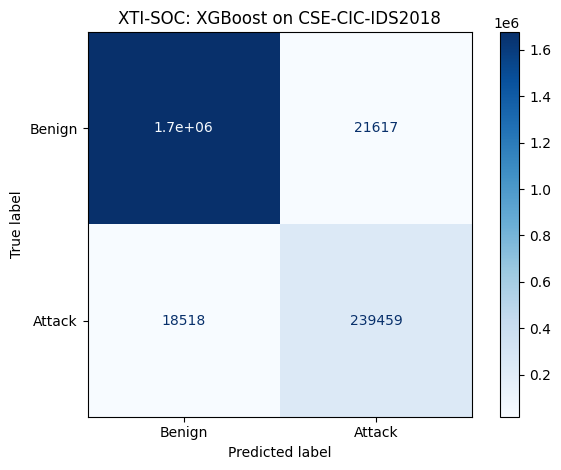

In [32]:
from sklearn.metrics import f1_score

y_pred = model.predict(X_test_scaled)

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Attack']))

print(f"FN rate: {((y_test==1)&(y_pred==0)).sum()/(y_test==1).sum()*100:.2f}%")
print(f"FP rate: {((y_test==0)&(y_pred==1)).sum()/(y_test==0).sum()*100:.2f}%")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Attack'])
disp.plot(cmap='Blues')
plt.title('XTI-SOC: XGBoost on CSE-CIC-IDS2018')
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_PATH, 'confusion_matrix.png'), dpi=150)
plt.show()

Cell 8 — Save Remaining Artifacts

In [34]:
# Feature list
with open(os.path.join(ARTIFACT_PATH, 'feature_list.pkl'), 'wb') as f:
    pickle.dump(FEATURES, f)
print(f"feature_list.pkl saved — {len(FEATURES)} features")

# SHAP explainer
print("Building SHAP TreeExplainer...")
explainer = shap.TreeExplainer(model)
with open(os.path.join(ARTIFACT_PATH, 'explainer.pkl'), 'wb') as f:
    pickle.dump(explainer, f)
print("explainer.pkl saved")

feature_list.pkl saved — 25 features
Building SHAP TreeExplainer...
explainer.pkl saved


Cell 9 — Verify All Artifacts

In [35]:
import numpy as np

print("=== ARTIFACT VERIFICATION ===\n")
for a in ['model.pkl', 'scaler.pkl', 'explainer.pkl', 'feature_list.pkl']:
    path = os.path.join(ARTIFACT_PATH, a)
    size = os.path.getsize(path) / 1024**2
    print(f"✓ {a:25s} {size:.1f} MB")

# Reload from disk
with open(os.path.join(ARTIFACT_PATH, 'model.pkl'), 'rb') as f:
    m = pickle.load(f)
with open(os.path.join(ARTIFACT_PATH, 'scaler.pkl'), 'rb') as f:
    sc = pickle.load(f)
with open(os.path.join(ARTIFACT_PATH, 'explainer.pkl'), 'rb') as f:
    ex = pickle.load(f)
with open(os.path.join(ARTIFACT_PATH, 'feature_list.pkl'), 'rb') as f:
    fl = pickle.load(f)

# Smoke test predict_proba
dummy = np.zeros((1, len(fl)), dtype='float32')
dummy_scaled = sc.transform(dummy)
proba = m.predict_proba(dummy_scaled)
print(f"\nSmoke test predict_proba: {proba}")

# SHAP smoke test — XGBoost safe
sv = ex.shap_values(X_test_scaled[:50])
print(f"SHAP output type: {type(sv)}")
print(f"SHAP shape: {sv.shape if hasattr(sv, 'shape') else [s.shape for s in sv]}")

if isinstance(sv, list):
    shap_array = sv[1]
else:
    shap_array = sv

assert shap_array.shape == (50, len(fl)), f"Shape mismatch: {shap_array.shape}"
print(f"SHAP smoke test passed — shape: {shap_array.shape}")

print("\n=== PHASE 0 COMPLETE ===")
print("All 4 artifacts verified. Ready for Phase 1.")

=== ARTIFACT VERIFICATION ===

✓ model.pkl                 3.3 MB
✓ scaler.pkl                0.0 MB
✓ explainer.pkl             12.6 MB
✓ feature_list.pkl          0.0 MB

Smoke test predict_proba: [[0.6534484 0.3465516]]
SHAP output type: <class 'numpy.ndarray'>
SHAP shape: (50, 25)
SHAP smoke test passed — shape: (50, 25)

=== PHASE 0 COMPLETE ===
All 4 artifacts verified. Ready for Phase 1.


=====DONE FOR SOME TESTING=====

In [37]:
print("=== SCALED FEATURE STATS (sample) ===")
import pandas as pd
stats = pd.DataFrame(X_train_scaled[:10000], columns=FEATURES).describe().round(3)
print(stats.loc[['mean', 'std', 'min', 'max']].to_string())

=== SCALED FEATURE STATS (sample) ===
      Flow Duration  Tot Fwd Pkts  Tot Bwd Pkts  TotLen Fwd Pkts  TotLen Bwd Pkts  Fwd Pkt Len Max  Fwd Pkt Len Min  Fwd Pkt Len Mean  Bwd Pkt Len Max  Bwd Pkt Len Min  Bwd Pkt Len Mean  Flow Byts/s  Flow Pkts/s  Flow IAT Mean  Fwd IAT Mean  Bwd IAT Mean  Fwd PSH Flags  FIN Flag Cnt  SYN Flag Cnt  RST Flag Cnt  PSH Flag Cnt  ACK Flag Cnt  Down/Up Ratio  Fwd Seg Size Avg  Bwd Seg Size Avg
mean          2.828         4.953         1.192            1.305            6.038            0.249            8.664             0.235            0.241           22.990             0.278        7.510        6.693          5.409         4.063         3.059          0.024         0.002         0.024         0.309        -0.402         0.188          0.497             0.235             0.278
std           5.993       312.337        40.929           70.437          241.836            0.533           22.817             0.772            0.506           50.487             

In [33]:
frames = []
for fname in FILES:
    fpath = os.path.join(DATA_PATH, fname)
    chunk = pd.read_csv(fpath, usecols=lambda c: c.strip() == 'Label', low_memory=False)
    chunk.columns = chunk.columns.str.strip()
    chunk = chunk[chunk['Label'] != 'Label']
    frames.append(chunk)

all_labels = pd.concat(frames, ignore_index=True)
df_clean = pd.read_pickle(os.path.join(CHECKPOINT_PATH, 'df_clean.pkl'))
all_labels_clean = all_labels.loc[df_clean.index].reset_index(drop=True)
del all_labels, df_clean; gc.collect()

all_labels_bin = (all_labels_clean['Label'] != 'Benign').astype(int)

_, test_idx = train_test_split(
    np.arange(len(all_labels_bin)),
    test_size=0.2,
    stratify=all_labels_bin,
    random_state=42
)

test_labels = all_labels_clean['Label'].iloc[test_idx].reset_index(drop=True)

missed_mask = (y_test == 1) & (y_pred == 0)
print("=== MISSED ATTACKS BY TYPE ===")
missed = test_labels[missed_mask].value_counts()
print(missed)

print("\n=== MISS RATE PER CLASS ===")
for attack in test_labels[y_test == 1].unique():
    total = (test_labels[y_test == 1] == attack).sum()
    missed_count = missed.get(attack, 0)
    rate = missed_count / total * 100
    print(f"{attack:<35} {missed_count:>6} / {total:>6} = {rate:.1f}%")

print(f"\nTotal missed: {missed_mask.sum():,}")

=== MISSED ATTACKS BY TYPE ===
Label
Benign                    16055
DDoS attacks-LOIC-HTTP     1148
DDOS attack-HOIC            359
Bot                         284
DoS attacks-Hulk            229
Infilteration               186
SSH-Bruteforce              161
DoS attacks-GoldenEye        76
DoS attacks-Slowloris        15
DDOS attack-LOIC-UDP          3
Brute Force -Web              2
Name: count, dtype: int64

=== MISS RATE PER CLASS ===
DDoS attacks-LOIC-HTTP                1148 /  15295 = 7.5%
Benign                               16055 / 223805 = 7.2%
DDOS attack-HOIC                       359 /   5191 = 6.9%
DoS attacks-Hulk                       229 /   3291 = 7.0%
DoS attacks-GoldenEye                   76 /   1115 = 6.8%
Bot                                    284 /   3793 = 7.5%
SSH-Bruteforce                         161 /   2452 = 6.6%
DoS attacks-Slowloris                   15 /    238 = 6.3%
Infilteration                          186 /   2729 = 6.8%
DDOS attack-LOIC-UDP     